In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.seterr(divide='ignore', invalid='ignore');
from matplotlib.ticker import MultipleLocator

In [2]:
## -- load data
dat_wavelengths, dat_spec, dat_specerr= np.loadtxt("./data/stellarspectra/V1298Tau_NIRISSobs17_fluxcal_medianspectrum.txt", skiprows=1, unpack=True)

## -- best-fit 3-component model
bfl = np.load('./data/stellarspectra/visit2_3comp_models_JWSTgrid_v1.npz')
bfwaves = bfl['waves']
bfyfull = bfl['yfull']

## -- 4-component models
# with contrast-fitted Tumb and Tpen
l1 = np.load('./data/stellarspectra/visit2_forwardmodel1.npz')
testwaves1 = l1['waves']
testspec1 = l1['spec']
del l1

# with higher Tumb and lower Thot
l2 = np.load('./data/stellarspectra/visit2_forwardmodel2.npz')
testwaves2 = l2['waves']
testspec2 = l2['spec']
del l2

# with higher Au/Ap
l3 = np.load('./data/stellarspectra/visit2_forwardmodel3.npz')
testwaves3 = l3['waves']
testspec3 = l3['spec']
del l3

In [3]:
cobs = 'black' # obs. spec.
c3comp = 'orange' # 3-comp. spec.
c4comp = 'red' # 4-comp spec.

cr4o = 'red' # ratio btwn 4-comp and obs.
cr43 = 'orange' # ratio btwn 4-comp and 3-comp
cr3o = 'purple' # ratio btwn 3-comp and obs.

cd4 = 'red' # residual btwn 4-comp and obs.
cd3 = 'orange' # residual btwn 3-comp and obs.

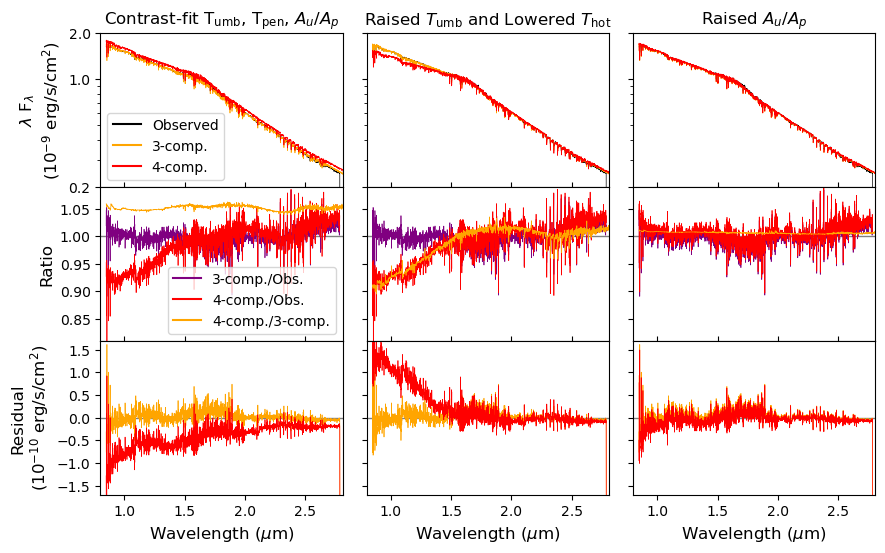

In [4]:
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(3, 3, hspace=0, wspace=0.1)

# Create axes, sharing y across each row
ax = [[None]*3 for _ in range(3)]
for col in range(3):
    ax[0][col] = fig.add_subplot(gs[0, col], sharex=ax[0][0] if col > 0 else None,
                                              sharey=ax[0][0] if col > 0 else None)
    ax[1][col] = fig.add_subplot(gs[1, col], sharex=ax[0][0],
                                              sharey=ax[1][0] if col > 0 else None)
    ax[2][col] = fig.add_subplot(gs[2, col], sharex=ax[0][0],
                                              sharey=ax[2][0] if col > 0 else None)

## left column -- test 1
# spectra
ax[0][0].set_title(r"Contrast-fit T$_{\mathrm{umb}}$, T$_{\mathrm{pen}}$, $A_u/A_p$", fontsize=12)
ax[0][0].plot(dat_wavelengths, dat_wavelengths*dat_spec/1.e-9, c=cobs, lw=0.5, label='Observed')
ax[0][0].plot(dat_wavelengths, dat_wavelengths*bfyfull/1.e-9, c=c3comp, lw=0.5, label='3-comp.')
ax[0][0].plot(dat_wavelengths, dat_wavelengths*testspec1/1.e-9, c=c4comp, lw=0.5, label=r'4-comp.')
ax[0][0].set_yscale('log')
ax[0][0].tick_params(axis='x', which='both', direction='in')
# ratio
ax[1][0].axhline(1.0, lw=1, c='gray')
ax[1][0].plot(dat_wavelengths, (bfyfull/dat_spec), c=cr3o, lw=0.5, label='3-comp./Obs.')
ax[1][0].plot(dat_wavelengths, (testspec2/dat_spec), c=cr4o, lw=0.5, label='4-comp./Obs.')
ax[1][0].plot(dat_wavelengths, (testspec1/bfyfull), c=cr43, lw=0.5, label='4-comp./3-comp.')
ax[1][0].set_ylabel('Ratio', fontsize=12)
ax[1][0].tick_params(axis='x', which='both', direction='in')
# residuals
ax[2][0].axhline(0., lw=1, c='gray')
ax[2][0].plot(dat_wavelengths, ((dat_wavelengths*dat_spec)-(dat_wavelengths*bfyfull))/1.e-10, c=cd3, lw=0.5, label='Obs. - 3-comp.')
ax[2][0].plot(dat_wavelengths, ((dat_wavelengths*dat_spec)-(dat_wavelengths*testspec1))/1.e-10, c=cd4, lw=0.5, label='Obs. - 4-comp.')
ax[2][0].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[2][0].set_xlim(0.8, 2.81)

## middle column -- test 2
# spectra
ax[0][1].set_title(r"Raised $T_{\mathrm{umb}}$ and Lowered $T_{\mathrm{hot}}$", fontsize=12)
ax[0][1].plot(dat_wavelengths, dat_wavelengths*dat_spec/1.e-9, c=cobs, lw=0.5)
ax[0][1].plot(dat_wavelengths, dat_wavelengths*bfyfull/1.e-9, c=c3comp, lw=0.5)
ax[0][1].plot(dat_wavelengths, dat_wavelengths*testspec2/1.e-9, c=c4comp, lw=0.5)
ax[0][1].set_yscale('log')
ax[0][1].tick_params(axis='x', which='both', direction='in')
# ratio
ax[1][1].axhline(1.0, lw=1, c='gray')
ax[1][1].plot(dat_wavelengths, (bfyfull/dat_spec), c=cr3o, lw=0.5)
ax[1][1].plot(dat_wavelengths, (testspec2/dat_spec), c=cr4o, lw=0.5)
ax[1][1].plot(dat_wavelengths, (testspec2/bfyfull), c=cr43, lw=0.5)
ax[1][1].tick_params(axis='x', which='both', direction='in')
# residuals
ax[2][1].axhline(0., lw=1, c='gray')
ax[2][1].plot(dat_wavelengths, ((dat_wavelengths*dat_spec)-(dat_wavelengths*bfyfull))/1.e-10, c=cd3, lw=0.5)
ax[2][1].plot(dat_wavelengths, ((dat_wavelengths*dat_spec)-(dat_wavelengths*testspec2))/1.e-10, c=cd4, lw=0.5)
ax[2][1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[2][1].set_xlim(0.8, 2.81)

## right column -- test 3
# spectra
ax[0][2].set_title(r"Raised $A_u/A_p$", fontsize=12)
ax[0][2].plot(dat_wavelengths, dat_wavelengths*dat_spec/1.e-9, c=cobs, lw=0.5)
ax[0][2].plot(dat_wavelengths, dat_wavelengths*bfyfull/1.e-9, c=c3comp, lw=0.5)
ax[0][2].plot(dat_wavelengths, dat_wavelengths*testspec3/1.e-9, c=c4comp, lw=0.5)
ax[0][2].set_yscale('log')
ax[0][2].tick_params(axis='x', which='both', direction='in')
# ratio
ax[1][2].axhline(1.0, lw=1, c='gray')
ax[1][2].plot(dat_wavelengths, (bfyfull/dat_spec), c=cr3o, lw=0.5)
ax[1][2].plot(dat_wavelengths, (testspec3/dat_spec), c=cr4o, lw=0.5)
ax[1][2].plot(dat_wavelengths, (testspec3/bfyfull), c=cr43, lw=0.5)
ax[1][2].tick_params(axis='x', which='both', direction='in')
# residuals
ax[2][2].axhline(0., lw=1, c='gray')
ax[2][2].plot(dat_wavelengths, ((dat_wavelengths*dat_spec)-(dat_wavelengths*bfyfull))/1.e-10, c=cd3, lw=0.5)
ax[2][2].plot(dat_wavelengths, ((dat_wavelengths*dat_spec)-(dat_wavelengths*testspec3))/1.e-10, c=cd4, lw=0.5)
ax[2][2].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[2][2].set_xlim(0.8, 2.81)

# Hide redundant y tick labels on shared axes
for row in range(3):
    for col in range(1, 3):
        ax[row][col].yaxis.set_tick_params(labelleft=False)

for col in range(1, 3):
    ax[0][col].yaxis.set_major_formatter(plt.NullFormatter())
    ax[0][col].yaxis.set_minor_formatter(plt.NullFormatter())
ax[0][0].yaxis.set_major_formatter(plt.ScalarFormatter())
ax[0][0].yaxis.set_minor_formatter(plt.NullFormatter())
ax[0][0].set_ylim(0.2,2)
ax[0][0].set_yticks([0.2,1.0,2.0])

#ax[1][0].set_yticks(np.arange(0.81,1.09,0.1))
ax[1][0].set_ylim(0.81,1.09)
ax[1][0].yaxis.set_major_locator(MultipleLocator(0.05))

ax[2][0].set_ylim(-1.7, 1.7)
ax[2][0].yaxis.set_major_locator(MultipleLocator(0.5))

ax[0][0].legend(loc='upper right', fontsize=10)
leg = ax[0][0].legend()
for line in leg.get_lines():
    line.set_linewidth(1.5)
ax[1][0].legend(loc='lower right', fontsize=10)
leg = ax[1][0].legend()
for line in leg.get_lines():
    line.set_linewidth(1.5)

ax[0][0].set_ylabel('$\lambda$ F$_\lambda$\n($10^{-9}$ erg/s/cm$^2$)', fontsize=12)
ax[2][0].set_ylabel('Residual\n($10^{-10}$ erg/s/cm$^2$)', fontsize=12)    

plt.savefig('./figures/Figure10_spectrumforwardmodeltests.pdf', dpi=600, bbox_inches='tight')
plt.show()